# Downloading Dataset

In [ ]:
!gdown 1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7

Downloading...
From (original): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7
From (redirected): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7&confirm=t&uuid=453f7d37-42d7-4ad6-a769-cb9205de941c
To: /content/finetune_sharegpt.jsonl
100% 194M/194M [00:02<00:00, 66.5MB/s]


# Examples

In [ ]:
import os
import time
import json
from tqdm import tqdm


with open('finetune_sharegpt.jsonl') as f:
  data = [json.loads(sample) for sample in f.readlines()]

In [ ]:
data[0]

{'id': 'rice_blast_001',
 'crop': 'rice',
 'symptom_text': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।',
 'image_path': None,
 'disease_label': 'Rice Blast (ধানের ব্লাস্ট)',
 'qa_flow': [{'role': 'assistant',
   'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
  {'role': 'user',
   'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
  {'role': 'assistant',
   'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
  {'role': 'user',
   'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'}],
 'advice': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সব

In [ ]:
def create_single_conversation(sample):

    single_sample = [{'role': 'user',
      'content': sample['symptom_text']
    }]

    for qa_entry in sample['qa_flow']:
      single_sample.append(qa_entry)

    single_sample.append({'role': 'assistant',
      'content': sample['advice'] + '\nNote: ' +  sample['notes']
    })

    return single_sample

In [ ]:
def fix_single_conversation(sample):
  merged = []
  last_role = None
  for s in sample:
    current_role = s['role']
    current_content = s['content']
    if last_role and last_role == current_role:
        merged[-1]['content'] += f'\n{current_content}'
    else:
        merged.append({'role': current_role, 'content': current_content})
        last_role = current_role
  return merged

# Data Structure

In [ ]:
dataset = []

for sample in tqdm(data):
  dataset.append(fix_single_conversation(create_single_conversation(sample)))

100%|██████████| 96311/96311 [00:00<00:00, 148769.42it/s]


In [ ]:
dataset[5]

[{'role': 'user',
  'content': 'ধানের পাতাগুলো দ্রুত হলুদ হয়ে যাচ্ছে এবং শুকিয়ে যাচ্ছে। মনে হচ্ছে যেন গাছ দুর্বল হয়ে পড়েছে।'},
 {'role': 'assistant',
  'content': 'পাতা হলুদ হওয়ার সাথে সাথে কি আপনি পাতায় কোনো ধরনের দাগ দেখতে পাচ্ছেন? যদি দেখেন, তাহলে দাগগুলো কেমন?'},
 {'role': 'user',
  'content': 'হ্যাঁ, পাতায় হালকা বাদামী রঙের ছোট ছোট দাগ দেখা যাচ্ছে। দাগগুলো প্রথমে ছোট ছিল, কিন্তু এখন বাড়ছে।'},
 {'role': 'assistant',
  'content': 'আপনি কি কাণ্ড বা কলার অংশে কোনো পরিবর্তন লক্ষ্য করেছেন? যেমন - কাণ্ড নরম হয়ে যাওয়া বা তাতে দাগ পড়া।'},
 {'role': 'user',
  'content': 'কাণ্ডটা একটু নরম মনে হচ্ছে, এবং সেখানেও হালকা বাদামী দাগ দেখা যাচ্ছে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের জমিতে শীথ ব্লাইট (Sheath Blight) রোগের লক্ষণ দেখা যাচ্ছে। এটি একটি গুরুতর রোগ, যা দ্রুত পুরো জমিতে ছড়িয়ে পড়তে পারে।\nএই রোগের জন্য Propiconazole গ্রুপের ছত্রাকনাশক ব্যবহার করুন। এছাড়া, রোগাক্রান্ত গাছগুলো দ্রুত সরিয়ে ফেলুন এবং জমিতে ভালোভাবে পানি নিষ্কাশনের ব্যবস্থা করুন।\nNote: শীথ ব্লাইট রোগের বিস্তার 

# Split

In [ ]:
train_dataset = dataset[:int(len(dataset) * 0.8)]
test_dataset = dataset[int(len(dataset) * 0.8):]

# Gemma3

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [ ]:
from unsloth import FastVisionModel
import torch

model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-3-4b-pt",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.4: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


model.safetensors:   0%|          | 0.00/4.38G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
    target_modules = "all-linear",
)

Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients


In [ ]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-3"
)

# Fine Tuning

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    processing_class=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor),
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        gradient_checkpointing = True,

        gradient_checkpointing_kwargs = {"use_reentrant": False},
        max_grad_norm = 0.3,
        warmup_ratio = 0.03,
        max_steps = 30,
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy="steps",
        optim = "adamw_torch_fused",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    )
)

Unsloth: Switching to float32 training since model cannot work with float16


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 96,311 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 38,497,792 of 4,338,577,264 (0.89% trained)


Step,Training Loss
1,2.850500
2,3.143600
3,2.508700
4,2.360700
5,2.208000
6,2.124900
7,1.858300
8,1.967700
9,1.761800
10,1.733700


In [ ]:
dataset[0]

[{'role': 'user',
  'content': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
 {'role': 'user',
  'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
 {'role': 'assistant',
  'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
 {'role': 'user',
  'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সবসময় পর্যাপ্ত পানি রাখুন।\nNote: ব্লাস্ট রোগ ধানের জন্য খুবই ক্ষতিকর। এটি দ্রুত ছড়াতে পারে এ

# Loss Curve

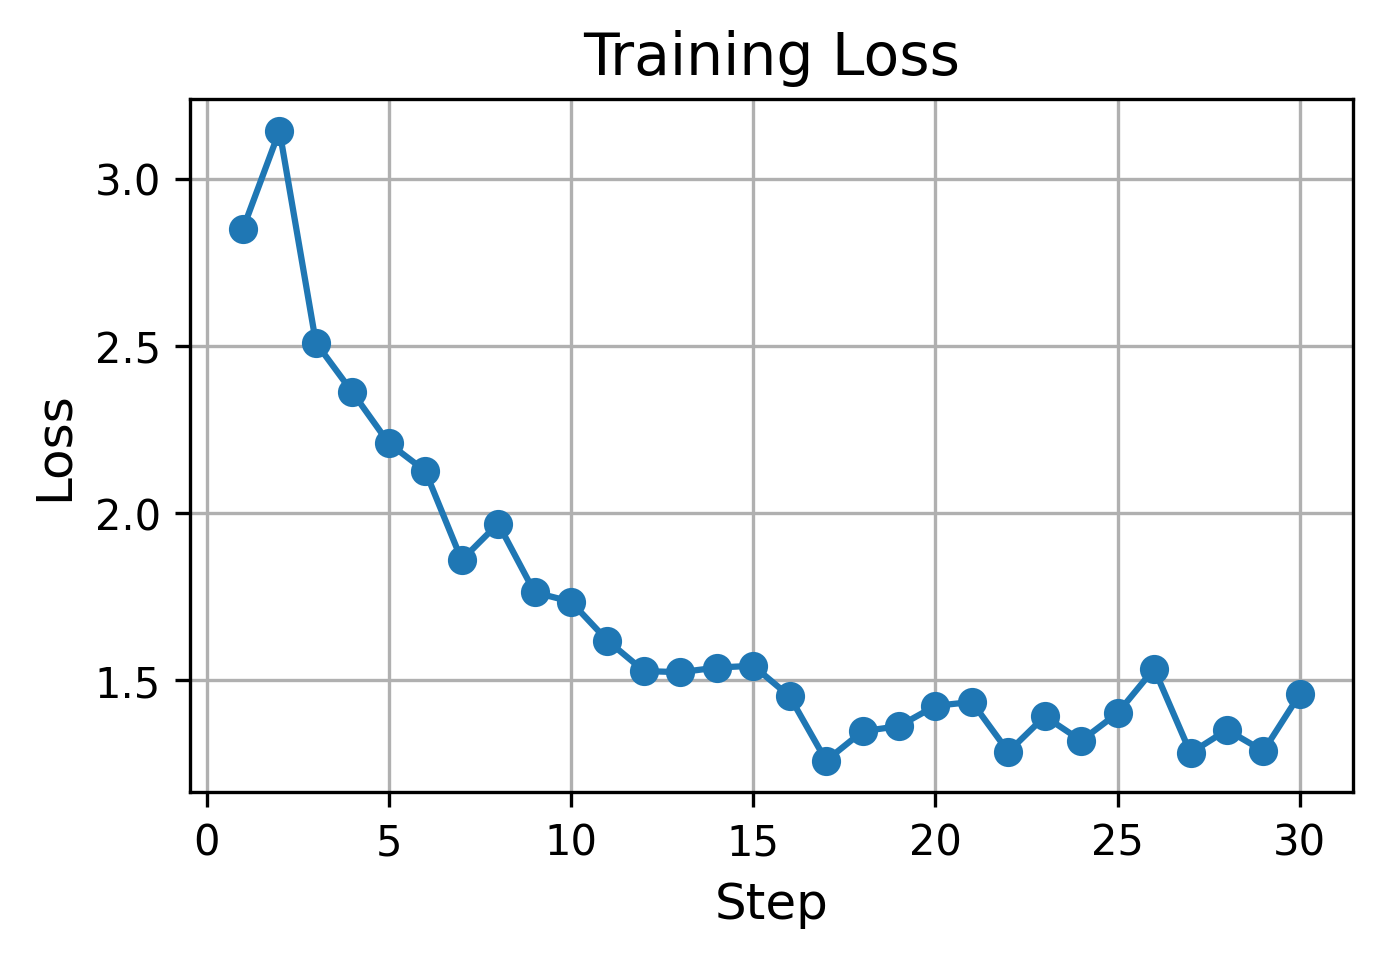

In [ ]:
import json
import matplotlib.pyplot as plt

file_path = "/content/outputs/checkpoint-30/trainer_state.json"

with open(file_path, 'r') as f:
    trainer_state = json.load(f)

log_history = trainer_state.get("log_history", [])

steps = [entry["step"] for entry in log_history]
losses = [entry["loss"] for entry in log_history]

plt.figure(figsize=(5, 3), dpi=300)
plt.plot(steps, losses, marker='o')
plt.title('Training Loss', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.grid(True)
plt.show()

# Save Model

In [ ]:
!rm -rf llama.cpp
!git clone --recursive https://github.com/ggerganov/llama.cpp
!cd llama.cpp && mkdir build && cd build && cmake .. && cmake --build .
!cp llama.cpp/convert_hf_to_gguf.py llama.cpp/unsloth_convert_hf_to_gguf.py


In [ ]:
# model.save_pretrained_gguf("model", processor.tokenizer, quantization_method = "q4_k_m")
model.save_pretrained_merged("model", processor.tokenizer, save_method = "merged_16bit")


# Evaluation

In [ ]:
def generate_conv(conv):
    input_text = processor.apply_chat_template(conv, add_generation_prompt=True)
    inputs = processor(
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=1000,
        use_cache=True,
        temperature=1.5,
        min_p=0.1
    )

    generated_text = processor.batch_decode(outputs, skip_special_tokens=True)[0].split("model\n")[-1]
    return generated_text

In [ ]:
single_conv = test_dataset[0]
for i in range(0, len(single_conv), 2):
  print('User: ', single_conv[:i + 1][-1]['content'])
  generated = generate_conv(single_conv[:i+1])
  print('LLM: ', generated)



User:  আমার ধান ক্ষেতে কিছু গাছের পাতা কুঁকড়ে যাচ্ছে এবং হলুদ হয়ে যাচ্ছে। গাছের বৃদ্ধিও খুব কম দেখাচ্ছে।
LLM:  আপনার ধানের পাতা কেন হলুদ হয়ে যাচ্ছে জানতে চাই। পাতার কুঁকড়ে যাওয়ার ঘটনা কি আপনার জন্য উদ্বেগের কারণ করছে?
User:  হ্যাঁ, পাতার শিরায় হালকা রেখা দেখা যাচ্ছে এবং গাছগুলোও তুলনামূলকভাবে খাটো।
LLM:  খালি রেখা দেখাচ্ছে এবং ছোট হয়ে যাওয়ার বিষয়গুলোও মনে করেন Rice Tungro রোগ নিয়ে।
User:  শিকড়গুলোও দুর্বল মনে হচ্ছে।
LLM:  আপনার ধানের জন্য অবশ্যই থায়ামেথক্সামের ব্যবহার করার প্রয়োজন। থাইয়ামেকন (4-4 কেজি/হেক্টর স্প্রে করার দিনার করার আগে স্প্রে করুন)। গাছগুলো যাতে সূর্যের আলোতে ভালভাবে পারে, সেটা খেয়াল রাখুন এবং জমিতে পানি জমে থাকতে দেওয়াও ভালো নয়। এই ব্যবস্থা নিলে ধান ক্ষেত ভালো করার আশা করতে পারেন।
Note :
ভালো সুস্থ, প্রয়োজনীয় পরিমাণে ফুঁক বাতাস রাখা এবং আবির ব্যবহার না করার উপর মনোযোগ দিন।
ধান ক্ষেত ভালো থাকবে।
আপনার কি অতিরিক্ত আবির ব্যবহার করেছেন কিনা?
User:  তাহলে এখন আমার কী করা উচিত?
LLM:  এক্ষেত্রে রোগমুক্ত seed দিয়ে ফসলে নতুন seeds বপন করা উচিত। রোগপ্রবণ ক্ষেতে কোনো seeds বপন না

In [ ]:
single_conv = test_dataset[1]
for i in range(0, len(single_conv), 2):
  print('User: ', single_conv[:i + 1][-1]['content'])
  generated = generate_conv(single_conv[:i+1])
  print('LLM: ', generated)



User:  ধানের কিছু পাতা হলুদ হয়ে যাচ্ছে এবং গাছগুলো দুর্বল হয়ে পড়ছে।
LLM:  পাতাগুলো কেমন লাগছে? পাতার কিনারাগুলোতে কি কোনো পার্থক্য লক্ষ্য করেন?
User:  পাতা হালকা সবুজ থেকে হলুদ এবং পরে কমলা হয়ে যাচ্ছে।
LLM:  পাতাগুলো কেমন এবং হলুদ হওয়ার মাত্রা কেমন?
পাতা সবুজ থেকে কমলা দিকে পরিবর্তন হচ্ছে?
User:  বৃদ্ধি খুব কম। গাছগুলো খাটো দেখাচ্ছে।
LLM:  আমি এখানে একটি নতুন এবং কার্যকর দমন ওষুধ - Imidacloprid ও Tricyclazole-এ থিতাবেন। Imidacloprid ১ মি. লিটারে (প্রতি লিটার পানির সাথে মিশিয়ে স্প্রে করবেন), এবং Tricyclazole ০.১২ গ. লিটারে (প্রতি লিটার পানিতে মিশিয়ে স্প্রে করবেন)। রোগের তীব্রতায় নির্ভর করে আপনাকে থিতাবার জন্য ৩-৪ সপ্তাহ এবং পরবর্তীতে এই দুটি ওষুধ মিশ্রণের সাথে এক বা দুবার (মাছির পোড়া বা Yellow Leaf Blight এবং ভাসমান ধানের গাছ কাটা না কেটে রেখে দিন)-ব্যবহার করতে হতে পারে। এই কাজগুলো ভালো ভাবে করার পরামর্শ দিচ্ছি।
User:  হ্যাঁ, শিরায় হালকা রেখা দেখা যাচ্ছে।
LLM:  এটা Rice Tungro রোগের শিরা রেখার অংশ। গাছের কিছু পাতাগুলো ইতিমধ্যেই শুকিয়ে গেছে?
User:  এই রোগের প্রতিকার কী?
LLM:  প্রতিপক্ষ-শ

In [ ]:
single_conv = []
while True:
  user_input = input('User: ')
  if user_input == 'exit':
    break
  single_conv.append({'role': 'user', 'content': user_input})
  generated = generate_conv(single_conv)
  print('LLM: ', generated)
  single_conv.append({'role': 'assistant', 'content': generated})



User: আমার ধান ক্ষেতে কিছু গাছের পাতা কুঁকড়ে যাচ্ছে এবং হলুদ হয়ে যাচ্ছে। গাছের বৃদ্ধিও খুব কম দেখাচ্ছে।
LLM:  এই পাতা হলুদ হওয়া এবং বৃদ্ধি কমে যাওয়ার কথা চিন্তা করানোর প্রয়োজন। পাতায় কি কোনো ধরনের দাগ/ছড়া/দড়ি?
User: পাতা হালকা সবুজ থেকে হলুদ এবং পরে কমলা হয়ে যাচ্ছে।
LLM:  এই পাতা শুকিয়ে কুঁকড়ো হয়ে যাওয়া একটি উল্লেখযোগ্য লক্ষণ, যা নেটের কথা মনে করাবে।
দাগ বা ছড়ায় কি মনে হচ্ছে?
User: পাতার শিরায় হালকা রেখা দেখা যাচ্ছে এবং গাছগুলোও তুলনামূলকভাবে খাটো।
LLM:  রেখা সম্ভবত স্পাইড্রার থ্রিট (পাতার শিরায় ছোট লাইন)। পাতাগুলো কি হলুদ বা সাদা রঙের, আর কি করে?
User: এখন আমার কী করা উচিত?
LLM:  Spiracyne spray করার জন্য থাইামিধল এবং মনসয়োতে একটি স্প্রে করবেন। একবারে পাতা স্পর্শ করবেন না, শুধু স্প্রে করার জন্য। গাছের সুস্থতায় ধীর হলেও সমস্যাটি হয়তো দ্রুত চলে যাবে।
User: exit


In [ ]:
from tqdm import tqdm

predictions = []
actuals = []
indices = len(test_dataset)

for j in tqdm(range(indices)):
    prompt = test_dataset[j][:-1]
    actual_response = test_dataset[j][-1]['content']
    generated_response = generate_conv(prompt)
    predictions.append(generated_response)
    actuals.append(actual_response)

In [ ]:
predictions[0]

'Rice Tungro রোগের কার্যকর কন্ট্রোলার হল Thidiazuron গ্রুপের কীটনাশক। এছাড়াও, এ সময়ে সরাসরি স্প্রে করা ভালো। CampoStar স্প্রে করে এই সমস্যা নিয়ন্ত্রণ করা যায়। আপনি CampoStar ব্যবহার করে দেখে নিতে পারেন। আপনার ধানের এই সমস্যার কারণে কিছু ফসলের উৎপাদন কমে যেতে পারে।\nআপনার ধানে নিয়মিতভাবে নজর দিন এবং ফসলের স্বাস্থ্য নিয়ে যত্নবান থাকুন।\nএই রোগের আক্রমণের বিষয়ে দ্রুত ব্যবস্থা না নিলে ফসল অনেকটাই খারাপ হওয়ার আশঙ্কা থাকতে পারে। তাই রোগ প্রতিরোধের ব্যবস্থা আগে নেওয়ার পরামর্শ দেওয়া যায়।\nNote : CampoStar কীটনাশকের নিরাপদ ব্যবহার নিশ্চিত করতে খেয়াল রাখতে হবে। কীটনাশকের নির্দেশিকা এবং নিয়মাবলি অনুসরণ করলে সমস্যা নিয়ন্ত্রণ করা যেতে পারে।'

In [ ]:
actuals[0]

'প্রথমে ক্ষেত থেকে সবুজ পাতা ফড়িং তাড়াতে হবে। এরপর Carbofuran, Phorate, Quinalphos, Imidacloprid, Thiamethoxam ব্যবহার করতে পারেন।\nক্ষেত থেকে সবুজ পাতা ফড়িং তাড়ান এবং Carbofuran, Phorate, Quinalphos, Imidacloprid, Thiamethoxam ব্যবহার করুন।\nNote: এটি একটি মারাত্মক ভাইরাসজনিত রোগ। সবুজ পাতা ফড়িং এর মাধ্যমে ছড়ায়। তাই ফড়িং নিয়ন্ত্রণ করা খুব জরুরি।'

In [ ]:
import nltk
nltk.download('wordnet')

!pip install rouge_score jiwer -q
class BengaliTokenizer:
    def tokenize(self, text):
        # For traditional metrics and TF-IDF, a simple whitespace split is often used
        return text.split()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
!pip install -q sentence-transformers bert-score -q

In [ ]:
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from collections import Counter
import math
import nltk
nltk.download('wordnet')
from rouge_score import rouge_scorer
from jiwer import wer

from bert_score import score
from sentence_transformers import SentenceTransformer, util

bleu_scores = []
meteor_scores = []
rouge1_fmeasures = []
rouge2_fmeasures = []
rougel_fmeasures = []
wer_scores = []
bert_p = []
bert_r = []
bert_f1 = []
cosine_similarities = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True, tokenizer=BengaliTokenizer())

# multilingual sentence transformer for cosine similarity
model_cs = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

for pred, ref in zip(predictions, actuals):

    pred_tokens = BengaliTokenizer().tokenize(pred)
    ref_tokens = BengaliTokenizer().tokenize(ref)

    # BLEU Score
    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=SmoothingFunction().method1)
    bleu_scores.append(bleu)

    # METEOR Score
    meteor = meteor_score([ref_tokens], pred_tokens)
    meteor_scores.append(meteor)

    # ROUGE Scores
    scores = scorer.score(ref, pred)
    rouge1_fmeasures.append(scores['rouge1'].fmeasure)
    rouge2_fmeasures.append(scores['rouge2'].fmeasure)
    rougel_fmeasures.append(scores['rougeL'].fmeasure)

    # WER Score
    wer_value = wer(ref, pred)
    wer_scores.append(wer_value)

    # BertScore (calculates P, R, F1 for each pair)
    # lang='bn' for Bengali
    P, R, F1 = score([pred], [ref], lang='bn', verbose=False)
    bert_p.append(P.item())
    bert_r.append(R.item())
    bert_f1.append(F1.item())

    # Cosine Similarity
    embeddings1 = model_cs.encode(pred, convert_to_tensor=True)
    embeddings2 = model_cs.encode(ref, convert_to_tensor=True)
    cosine_score = util.cos_sim(embeddings1, embeddings2).item()
    cosine_similarities.append(cosine_score)

print("BLEU:", np.mean(bleu_scores))
print("METEOR:", np.mean(meteor_scores))
print("ROUGE-1 F-measure:", np.mean(rouge1_fmeasures))
print("ROUGE-2 F-measure:", np.mean(rouge2_fmeasures))
print("ROUGE-L F-measure:", np.mean(rougel_fmeasures))
print("WER:", np.mean(wer_scores))
print("BertScore Precision:", np.mean(bert_p))
print("BertScore Recall:", np.mean(bert_r))
print("BertScore F1:", np.mean(bert_f1))
print("Cosine Similarity:", np.mean(cosine_similarities))

def calculate_ngram_perplexity(corpus, n=2):
    tokens = " ".join(corpus).split()
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    ngram_counts = Counter(ngrams)
    context_counts = Counter([ng[:-1] for ng in ngrams])

    log_prob = 0
    N = len(ngrams)

    if N == 0: return float('inf')

    for ng in ngrams:
        context = ng[:-1]
        if context_counts[context] == 0:
            prob = 0
        else:
            prob = ngram_counts[ng] / context_counts[context]

        if prob > 0:
            log_prob += math.log(prob)
        else:
            log_prob += math.log(1e-10)

    return math.exp(-log_prob / N)

print("Perplexity:", calculate_ngram_perplexity(predictions, n=2))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


BLEU: 0.00984042053990713
METEOR: 0.0779743840961539
ROUGE-1 F-measure: 0.12405130443696337
ROUGE-2 F-measure: 0.017588258888948098
ROUGE-L F-measure: 0.08938959560752378
WER: 1.2432869046281265
BertScore Precision: 0.7007656300067902
BertScore Recall: 0.685063903927803
BertScore F1: 0.6922618818283081
Cosine Similarity: 0.570267405807972
Perplexity: 4.916359325220864
